# OSQP oefeningen, deel 2

**Optimalisatie van Macronutriënten in Maaltijden**

Een topatleet streeft ernaar om zijn of haar dagelijkse voeding zorgvuldig af te stemmen op een specifieke verhouding van macronutriënten, namelijk proteïne, koolhydraten en vetten. De beschikbare ingrediënten voor deze maaltijden zijn broccoli ($B$), kalkoenfilet ($K$) en aardappelen ($A$), waarbij de hoeveelheden van elk ingrediënt in grammen moeten worden bepaald.

Er is de volgende nutritionele info beschikbaar over de ingrediënten:
- 100g Broccoli: 2.8g proteïne, 7g koolhydraten, 0.4g vetten
- 100g Kalkoenfilet: 29g proteïne, 0g koolhydraten, 7g vetten
- 100g Aardappelen:  2g proteïne, 17g koolhydraten, 0.1g vetten

Het doel is om de hoeveelheden van deze ingrediënten ($x_B$, $x_K$, $x_A$) te vinden die de afwijkingen van de gewenste doelhoeveelheden voor proteïne ($P$), koolhydraten ($C$) en vetten ($F$) minimaliseren. Dit optimalisatieprobleem kan worden gemodelleerd als een lineair programmeringsprobleem.

Heel concreet kun je starten met $P = 37, C = 41, F = 20$. Er zijn bovendien nog een aantal dingen om rekening mee te houden:
- De atleet eet in totaal exact 200g
- daarvan is de hoeveelheid broccoli tussen 200 en 300 gram
- de hoeveelheid kalkoen ligt tussen 100 en 200 gram
- de hoeveelheid aardappelen tussen 200 en 400 gram

### Stappenplan

1. Het moeilijkste is het omzetten van de zin *'Het doel is om de hoeveelheden van deze ingrediënten ($x_B$, $x_K$, $x_A$) te vinden die de afwijkingen van de gewenste doelhoeveelheden voor proteïne ($P$), koolhydraten ($C$) en vetten ($F$) minimaliseren.'* in een goede kostfunctie. Daar gaan we mee beginnen.

    - Hoe druk je uit dat de totale proteïnen dicht bij de waarde van P blijven ? Je moet hier een uitdrukking maken die $P$ (of gewoon 37) in verband brengt met de hoeveelheid proteïnen die je krijgt uit broccoli, kalkoen en aardappelen samen te brengen. Je wil in essentie dat het verschil tussen die twee dingen, klein is. Druk dit uit in een functie
    - Indien je in de vorige stap de absolute waarde hebt gebruikt om uit te drukken dat iets klein moet zijn, dan mag je die nu vervangen door de kwadraatfunctie. Ook die drukt een afstand uit, en is makkelijker om mee te (laten) rekenen.
    - Zoek een gelijkaardige uitdrukking voor $C$ en $F$.
    - De kostfunctie is nu de optelsom van deze 3 uitdrukkingen --> dit moeten we zo klein mogelijk maken.

*Oplossing*: $ Z = (P - (2.8x_B + 29x_K + 2x_A))² + (C - (7x_B + 0x_K + 17x_A))² + (F - (0.4x_B + 7x_K + 0.1x_A))²$

Nu kan je www.wolframalpha.com gebruiken om deze uitdrukking te laten uitrekenen.  Je moet wel, als je iets aan Wolfram vraagt werken met variabelen x, y, z: iets anders kent Wolfram Alpha niet. Dus je vervangt $x_B$ door $x$, $x_K$ door $y$ etc. Je had ook in het begin meteen deze variabelen kunnen kiezen. Wolfram geeft een uitdrukking terug:

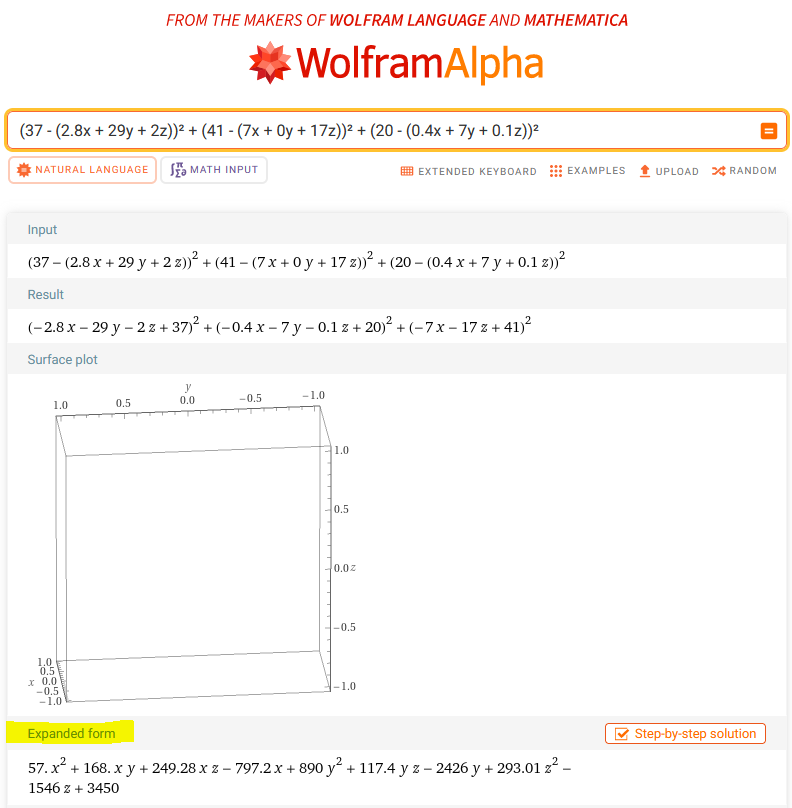

Deze uitdrukking moet je nu omzetten naar een matrixvorm:
De tabel hieronder toont hoe je zo'n uitdrukking terug kan omzetten in een matrix $P$, die je dus nodig hebt voor OSQP:

$$ P = \begin{bmatrix}
  a & d & e \\
  d & b & f \\
  e & f & c \\
\end{bmatrix} $$

Tabel
| Label | de coëfficient van |
|-------|-------------|
| a     |      $x_B^2$       |
| b     |      $x_K^2$      |
| c     |      $x_A^2$       |
| d     |      $x_B x_K$ / 2      |
| e     |      $x_B x_A$ / 2      |
| f     |      $x_K x_A$ / 2      |


Opgelet, de onderste 3 coëfficiënten kunnen we niet rechtstreeks aflezen: we moeten wat we aflezen door 2 delen en dat voor de letterwaarde invullen.

In [ ]:
# bepaal hier de matrix P

Er komen nog waarden uit deze uitdrukking (de lineaire stukken). Die horen tot de vector $q$:

In [ ]:
q = np.array([-797, -2626, -1546])

**Constraints**

Nu moeten we nog constraints omzetten in de matrix A, en de boven- en ondergrenzen u en l.

Wat zijn zinnige randvoorwaarden voor dit probleem ?

*oplossing*
$$
\begin{align*}
\text{Randvoorwaarden} & \\
&x_B, x_K, x_A \geq 0 \quad \text{(hoeveelheden kunnen niet negatief zijn!)} \\
&2 \leq x_B \leq 3 \qquad \text{(ik eet zeker tussen 200 en 300g broccoli)}  \\
&1 \leq x_K \leq 2 \\
&2 \leq x_A \leq 4 \\
& x_B + x_K + x_A = 7 \qquad \text{(ik eet in totaal 700g)} \\
\end{align*}
$$

In code:

In [ ]:
#TODO

Nu kun je OSQP het werk laten doen

In [ ]:
#TODO
